### 1.7. Task Submission - Network Vizzes

#### Importing libraries and relationship file:

In [1]:
#importing libraries
!pip install pyvis
!pip install seaborn
!pip install cdlib
!pip install python-igraph leidenalg

import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from pyvis.network import Network
import seaborn as sns
import pyvis

In [2]:
#import relationship data
relationship_df = pd.read_csv('countries_relationship.csv', index_col = 0)

In [3]:
relationship_df

,source,target,value
0,Austria,France,6
1,Austria,Hungary,6
2,Hungary,Russia,5
3,Germany,Russia,21
4,Germany,Ukraine,10
...,...,...,...
89,Rwanda,South Africa,5
90,North Korea,Rwanda,2
91,Germany,Norway,6
92,Romania,Russia,6


#### creating a network object
-from the countries relationships dataframe

In [4]:
#create a graph from a pandas dataframe
G = nx.from_pandas_edgelist(relationship_df, 
                            source = "source", 
                            target = "target", 
                            edge_attr = "value", 
                            create_using = nx.Graph())

#### creating a static network graph 
- using only NetworkX.


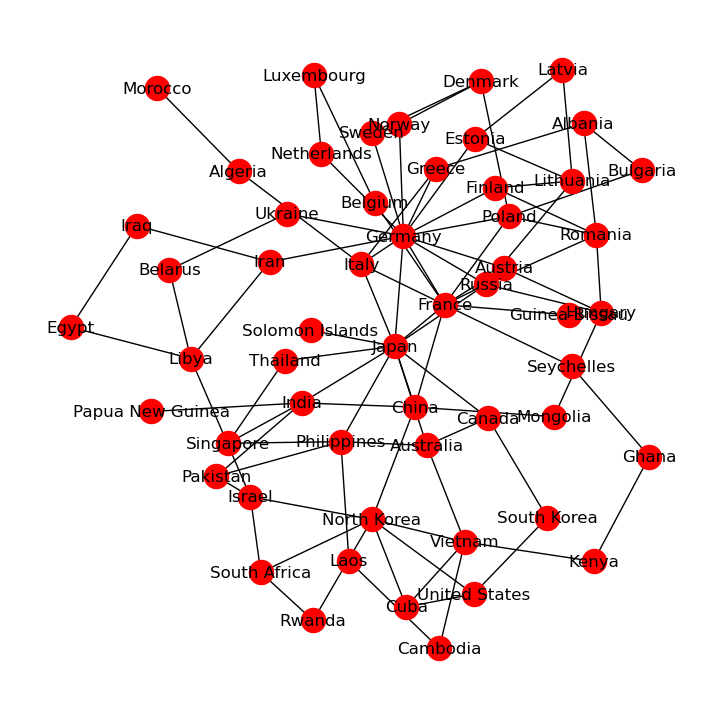

In [5]:
h = plt.figure(figsize = (7,7))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, with_labels = True, node_color = 'red', edge_cmap = plt.cm.Blues, pos = pos)
plt.show() 

#### building an interactive network graph from the network object
- switching to pyvis and saving it as an HTML file

In [6]:
#defining net object
net = Network()
net = Network(notebook = True,width="900px", height="800px", bgcolor='#222222', font_color='white')

#defining nodes from the G object
node_degree = dict(G.degree)

#setting up node size attributes
nx.set_node_attributes(G, node_degree, 'size')
net.from_nx(G)
net.show_buttons(filter_ = True)
net.repulsion()
net.show("countries.html") # this saves it

countries.html


#### applying the Leiden algorithm to detect any communities within the countries

In [7]:
from cdlib import algorithms
coms = algorithms.leiden(G)

Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'graph_tool', 'wurlitzer', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}


In [8]:
type(coms)

cdlib.classes.node_clustering.NodeClustering

In [9]:
new_com = coms.to_node_community_map()

In [10]:
new_com

defaultdict(list,
            {'Japan': [0],
             'China': [0],
             'Thailand': [0],
             'Singapore': [0],
             'Philippines': [0],
             'Australia': [0],
             'Solomon Islands': [0],
             'India': [0],
             'Pakistan': [0],
             'Papua New Guinea': [0],
             'Canada': [0],
             'Germany': [1],
             'Italy': [1],
             'Poland': [1],
             'Denmark': [1],
             'Norway': [1],
             'Sweden': [1],
             'Greece': [1],
             'Albania': [1],
             'Algeria': [1],
             'Morocco': [1],
             'Bulgaria': [1],
             'Israel': [2],
             'North Korea': [2],
             'South Africa': [2],
             'Laos': [2],
             'Cambodia': [2],
             'Vietnam': [2],
             'Cuba': [2],
             'United States': [2],
             'South Korea': [2],
             'Rwanda': [2],
             'Austria': [3]

Leiden algorithm detects 5 communities of countries in the dataset.

In [11]:
#putting the output from new_com into a dictionary
dict_com = {k:v[0] for k,v in new_com.items()}

In [12]:
dict_com

{'Japan': 0,
 'China': 0,
 'Thailand': 0,
 'Singapore': 0,
 'Philippines': 0,
 'Australia': 0,
 'Solomon Islands': 0,
 'India': 0,
 'Pakistan': 0,
 'Papua New Guinea': 0,
 'Canada': 0,
 'Germany': 1,
 'Italy': 1,
 'Poland': 1,
 'Denmark': 1,
 'Norway': 1,
 'Sweden': 1,
 'Greece': 1,
 'Albania': 1,
 'Algeria': 1,
 'Morocco': 1,
 'Bulgaria': 1,
 'Israel': 2,
 'North Korea': 2,
 'South Africa': 2,
 'Laos': 2,
 'Cambodia': 2,
 'Vietnam': 2,
 'Cuba': 2,
 'United States': 2,
 'South Korea': 2,
 'Rwanda': 2,
 'Austria': 3,
 'France': 3,
 'Netherlands': 3,
 'Luxembourg': 3,
 'Belgium': 3,
 'Kenya': 3,
 'Ghana': 3,
 'Seychelles': 3,
 'Guinea-Bissau': 3,
 'Hungary': 4,
 'Russia': 4,
 'Estonia': 4,
 'Latvia': 4,
 'Lithuania': 4,
 'Finland': 4,
 'Romania': 4,
 'Mongolia': 4,
 'Ukraine': 5,
 'Belarus': 5,
 'Libya': 5,
 'Egypt': 5,
 'Iraq': 5,
 'Iran': 5}

In [13]:
#rerun network graph with the communities as an argument
nx.set_node_attributes(G, dict_com, 'group')
com_net = Network(notebook = True, width="1300px", height="700px", bgcolor='#222222', font_color='white')
com_net.from_nx(G)
com_net.show_buttons(filter_ = True)
com_net.repulsion()
com_net.show("countries_communities_leiden.html") # this saves the file as html

countries_communities_leiden.html


#### Visualizing the output of the communities algorithm on the network graph:
 - Does the partition make sense according to history?
 - What other conclusions can be made about the connections between the communities?

With help of claude.AI:
### Community Analysis — Leiden Algorithm

The Leiden algorithm detected **6 communities** of countries in the dataset. 
Each community groups countries that are frequently mentioned together in the text.

#### Community 0 — Western and Southern Europe
`Austria, France, Germany, Italy, Poland, Denmark, Norway, Sweden, Netherlands, 
Luxembourg, Belgium, Greece, Albania, Algeria, Morocco, Guinea-Bissau, Bulgaria`

This grouping makes complete historical sense — these are the countries of the 
**European theatre of World War II**, along with some French colonies in North Africa.

#### Community 1 — Asia-Pacific
`Japan, China, Thailand, Singapore, Philippines, Australia, Solomon Islands, India, 
Pakistan, Papua New Guinea, Canada`

This represents the **Pacific theatre** of World War II, plus former British colonies. 
Canada appears here likely due to its participation in Pacific campaigns.

#### Community 2 — Cold War and Post-War Conflicts
`Israel, North Korea, South Korea, United States, Cuba, Vietnam, Laos, Cambodia, 
South Africa, Rwanda`

These are the countries associated with **Cold War conflicts** — the Korean War, 
the Vietnam War, and the Cuban Missile Crisis.

#### Community 3 — Eastern Europe and the Soviet Bloc
`Hungary, Russia, Estonia, Latvia, Lithuania, Finland, Romania, Mongolia`

These are the countries of the **Soviet bloc** and the Baltic states.

#### Community 4 — Middle East and Eastern Europe
`Ukraine, Belarus, Libya, Egypt, Iraq, Iran`

An interesting mix of **Middle Eastern** countries and former Soviet sphere nations.

#### Community 5 — Sub-Saharan Africa
`Kenya, Ghana, Seychelles, Rwanda`

Countries linked to the **African decolonization** process of the 20th century.

---

#### Why are there 6 colours in the network graph?

There are 6 colours because the Leiden algorithm detected **6 distinct communities** 
of countries that are frequently mentioned together in the text. Each colour represents 
a group of countries with stronger connections among themselves than with the other groups 
— essentially capturing the different **geopolitical theatres of the 20th century**.

What is remarkable is that the algorithm, without any prior historical knowledge, 
was able to group the countries in a historically coherent way, effectively 
"rediscovering" the major geopolitical blocs of the 20th century purely by analysing 
which countries are mentioned together in a Wikipedia article.

#### calculating and visualizing the degree, closeness, and betweenness centrality measures. 

In [ ]:
#degree centrality
degree_dict = nx.degree_centrality(G)

In [15]:
#making a dataframe
degree_df = pd.DataFrame(degree_dict.items(), columns=['countries','centrality'])

In [24]:
#sorting it
degree_df.sort_values(by = ['centrality'], ascending=False, inplace = True)
degree_df

,countries,centrality
4,Germany,0.259259
25,Japan,0.203704
1,France,0.185185
37,North Korea,0.129630
3,Russia,0.111111
6,Italy,0.092593
7,Poland,0.092593
28,China,0.092593
47,Romania,0.092593
42,Vietnam,0.092593


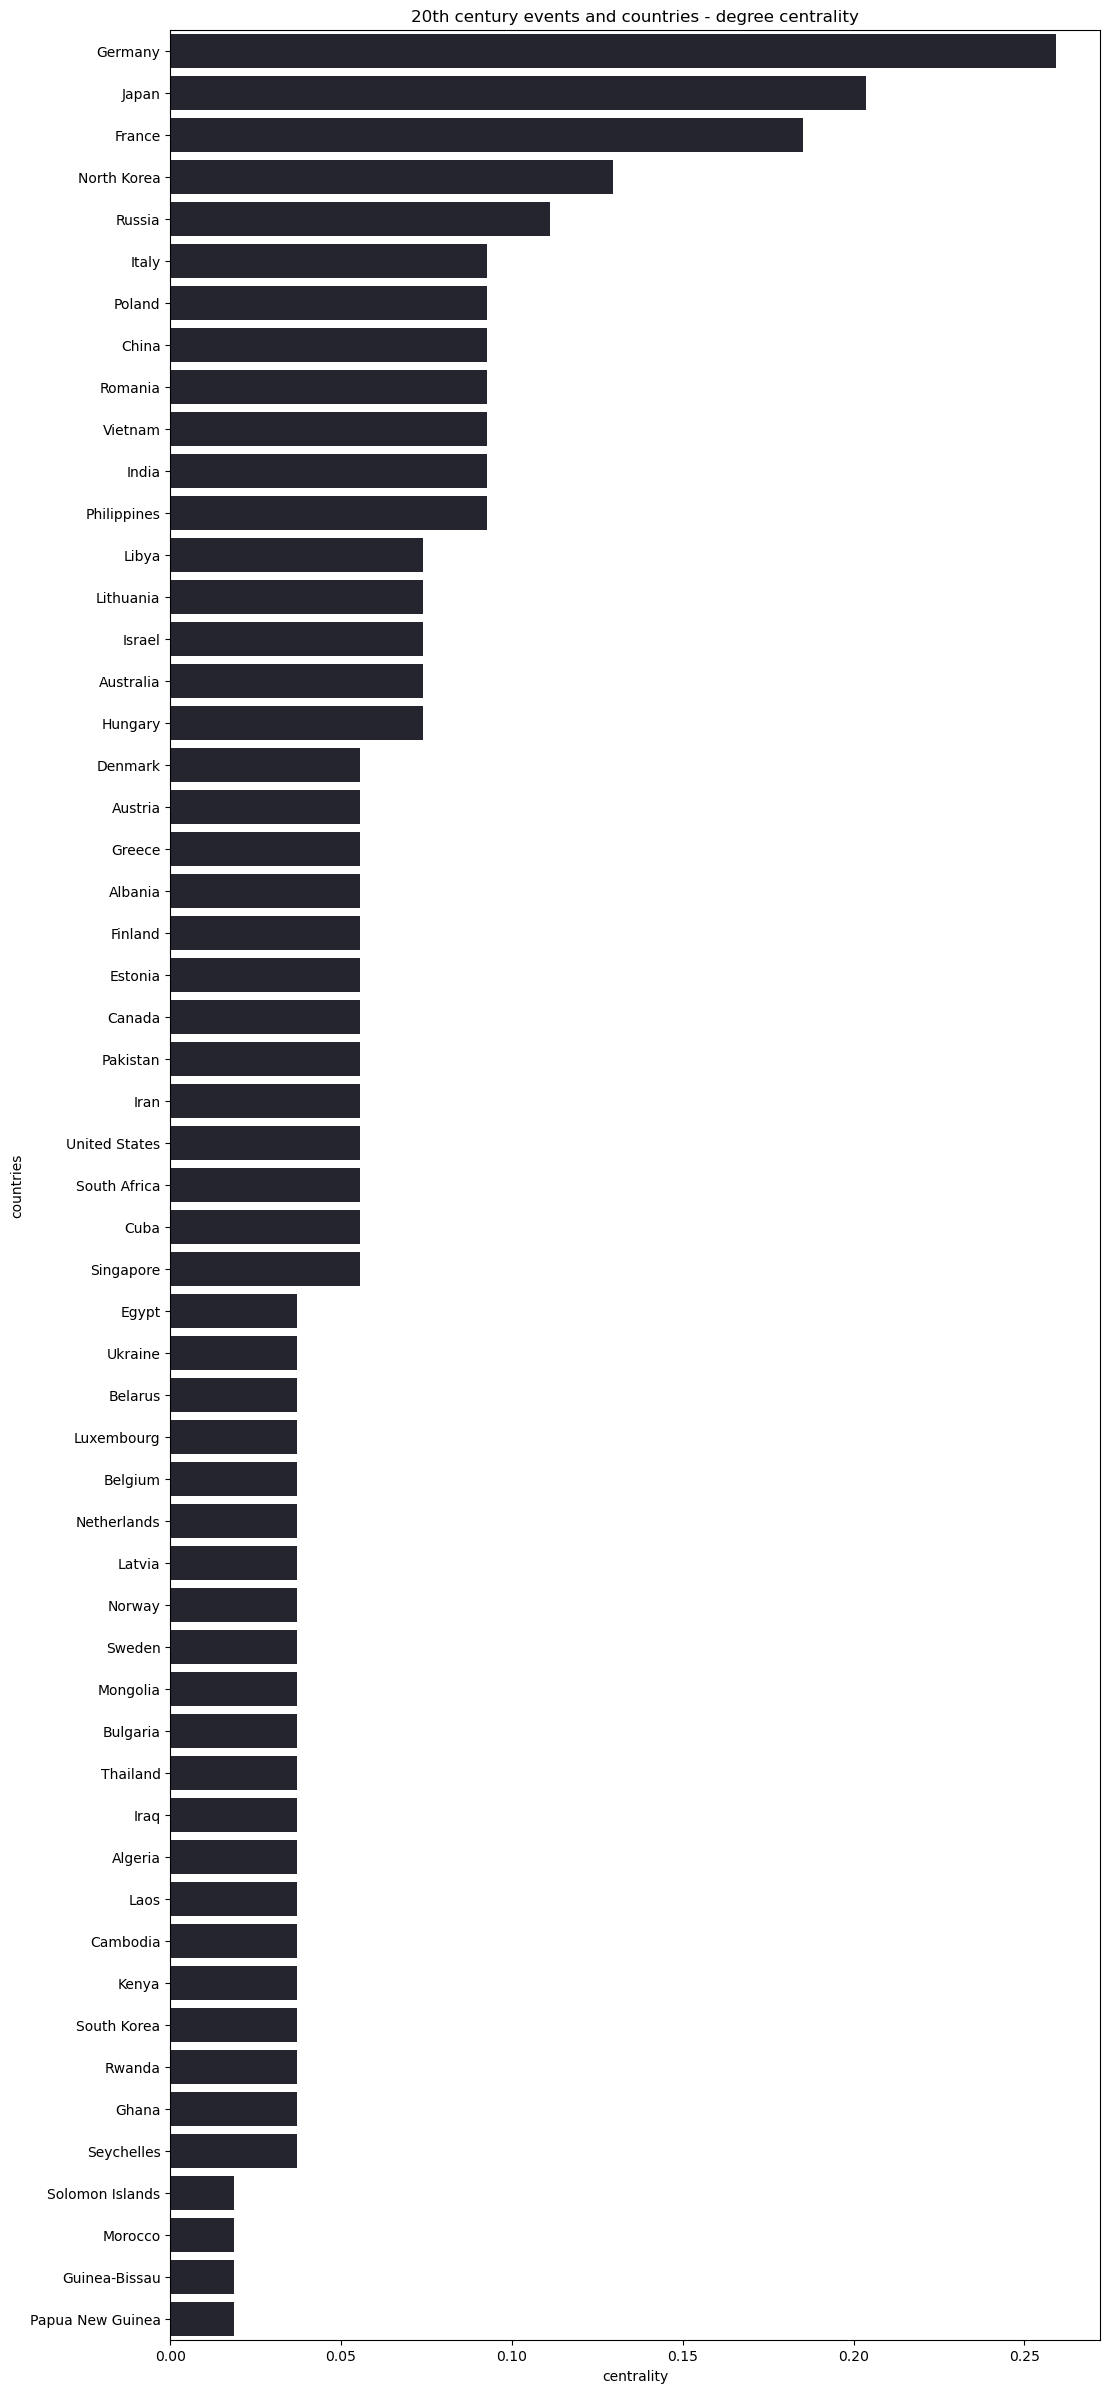

In [17]:
#plot the degree centrality
plt.figure(figsize = (12, 30))
with sns.dark_palette("xkcd:blue", 22):
    sns.barplot(x = "centrality", y = "countries",
    saturation = 0.9, data = degree_df).set_title("20th century events and countries - degree centrality")

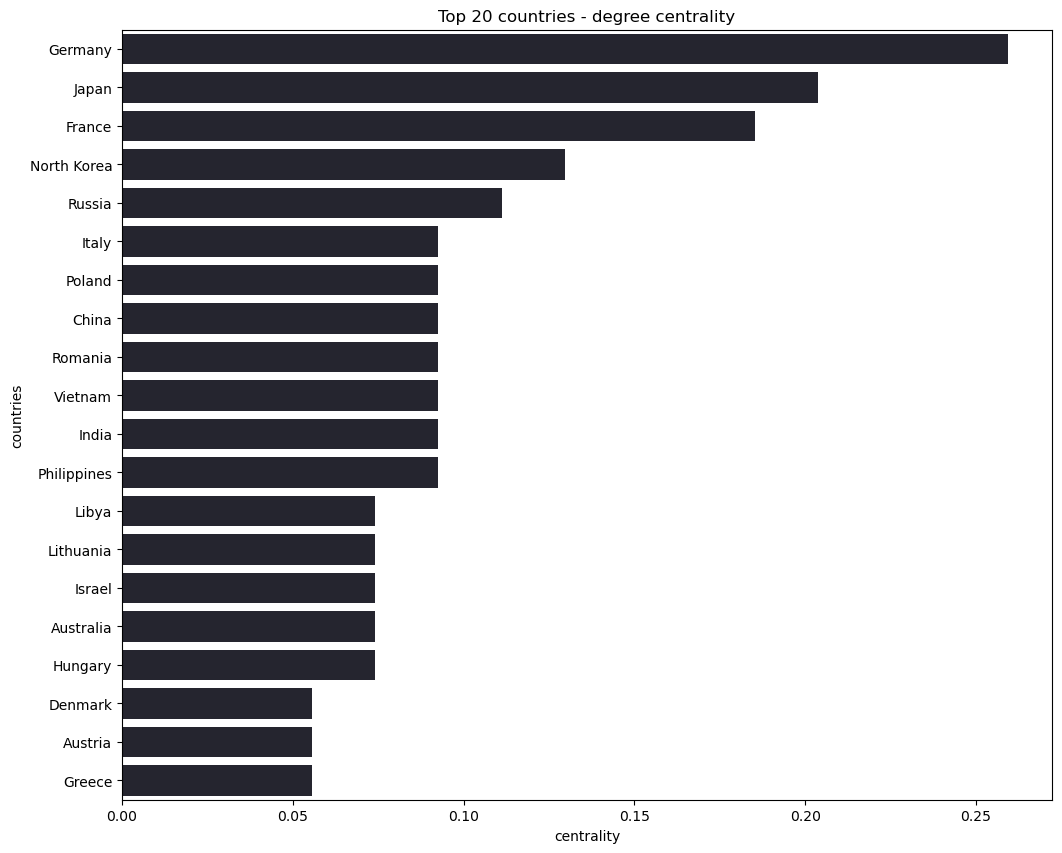

In [18]:
#showing only the top 20:
top_df = degree_df.sort_values(by="centrality", ascending=False).head(20)

plt.figure(figsize=(12, 10))
with sns.dark_palette("xkcd:blue", 22):
    sns.barplot(x="centrality", y="countries", saturation = 0.9, data = top_df).set_title("Top 20 countries - degree centrality")

In [ ]:
#closeness centrality
closeness_dict = nx.closeness_centrality(G)
closeness_df = pd.DataFrame(closeness_dict.items(), columns=['countries','centrality'])

In [25]:
closeness_df.sort_values(by = ['centrality'], ascending=False, inplace = True)
closeness_df

,countries,centrality
25,Japan,0.465517
4,Germany,0.457627
1,France,0.450000
28,China,0.400000
3,Russia,0.400000
6,Italy,0.391304
32,Australia,0.362416
7,Poland,0.360000
31,Philippines,0.355263
34,India,0.355263


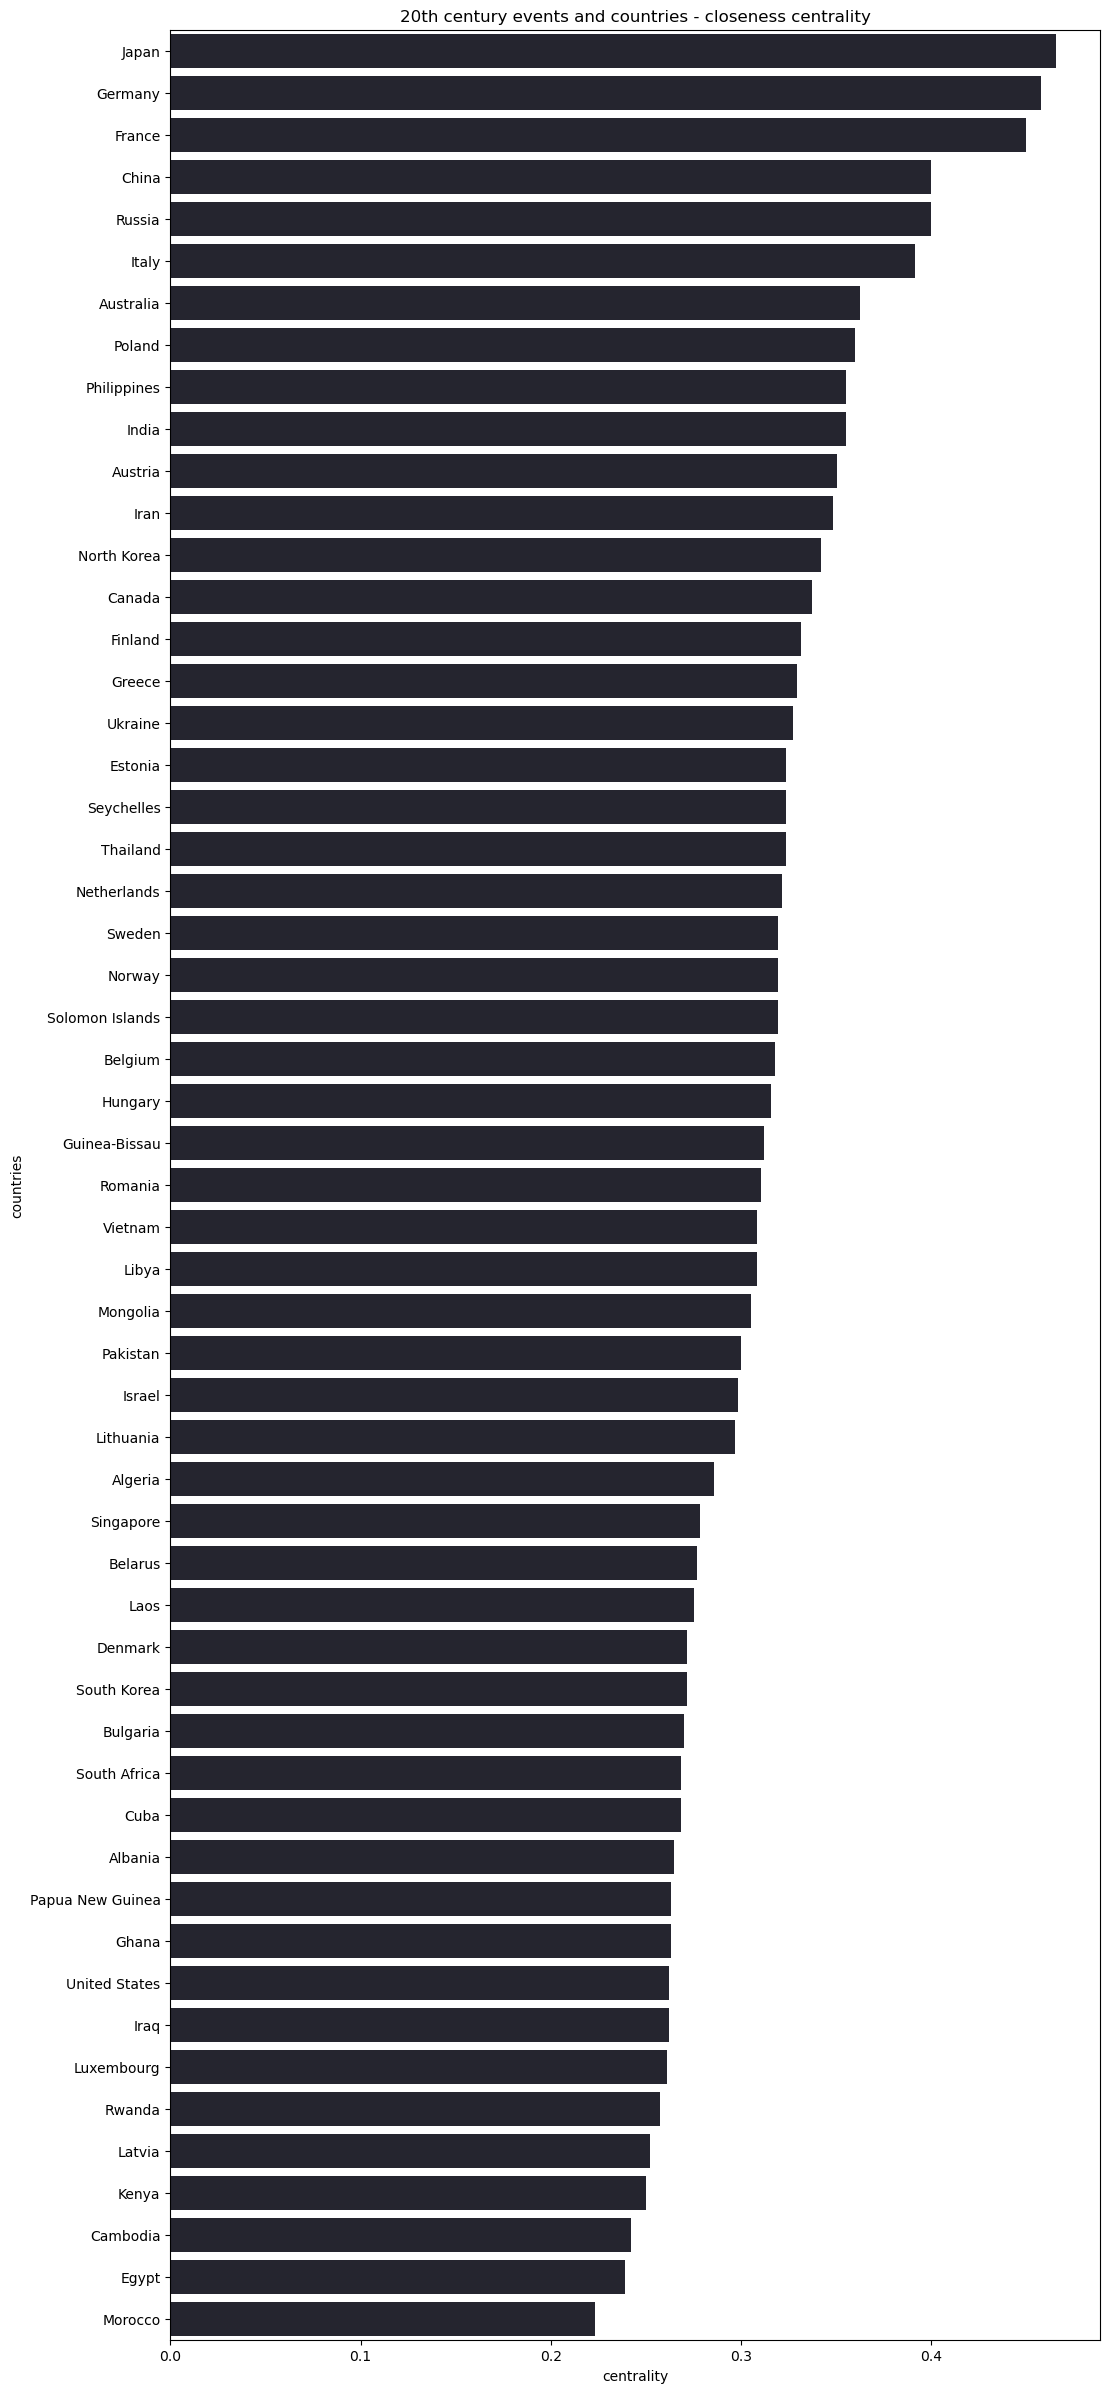

In [21]:
plt.figure(figsize = (12, 30))
with sns.dark_palette("xkcd:blue", 22):
    sns.barplot(x = "centrality", y = "countries",
    saturation = 0.9, data = closeness_df).set_title("20th century events and countries - closeness centrality")

In [ ]:
#betweenness centrality
betweenness_dict = nx.betweenness_centrality(G)
betweenness_df = pd.DataFrame(betweenness_dict.items(), columns=['countries','centrality'])

In [27]:
betweenness_df.sort_values(by = ['centrality'], ascending=False, inplace = True)
betweenness_df

,countries,centrality
4,Germany,0.377976
25,Japan,0.342020
1,France,0.232752
37,North Korea,0.149866
28,China,0.148548
6,Italy,0.086980
24,Iran,0.085589
3,Russia,0.078452
42,Vietnam,0.069425
31,Philippines,0.068817


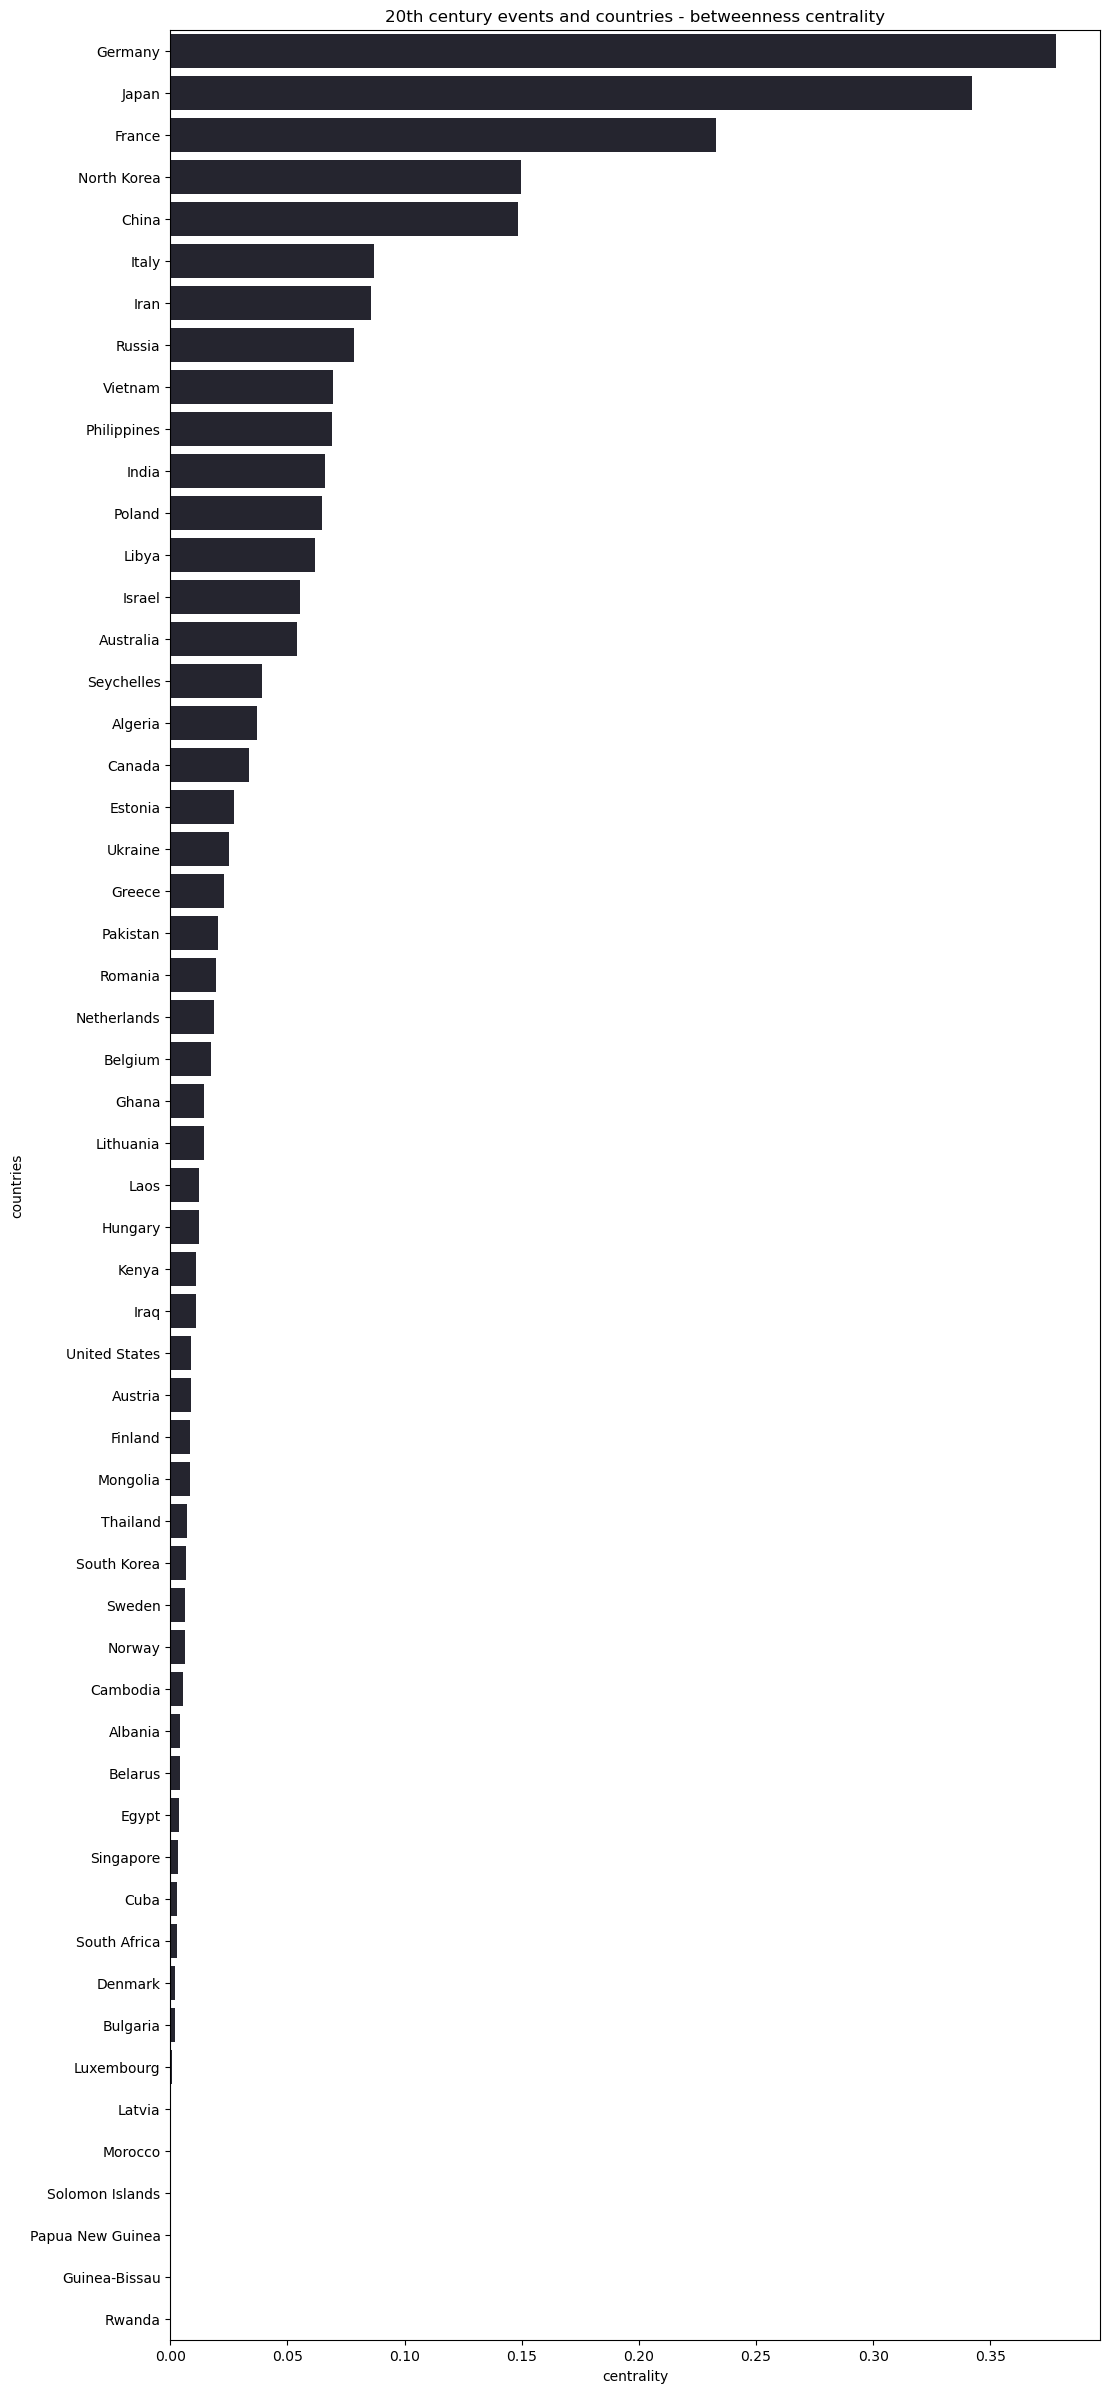

In [28]:
plt.figure(figsize = (12, 30))
with sns.dark_palette("xkcd:blue", 22):
    sns.barplot(x = "centrality", y = "countries",
    saturation = 0.9, data = betweenness_df).set_title("20th century events and countries - betweenness centrality")

````python
#save centrality measures
nx.set_node_attributes(G, degree_dict, 'degree_centrality')
nx.set_node_attributes(G, betweenness_dict, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_dict, 'closeness_centrality')

#### Observations about the outputs:
-with the help of claude.AI:
### Centrality Measures Analysis

Centrality measures help us understand the importance and role of each country 
in the network. There are three types of centrality measures used here:

---

#### 1. Degree Centrality
Degree centrality measures how many direct connections a country has with other 
countries in the network. The higher the score, the more countries it is 
directly mentioned with.

**Top countries:**
- **Germany (0.26)** — the most connected country in the network, mentioned 
alongside more countries than any other. This reflects Germany's central role 
in both World Wars and the Cold War.
- **Japan (0.20)** — the second most connected, reflecting its involvement in 
the Pacific theatre of World War II.
- **France (0.19)** — highly connected, reflecting its role in both World Wars 
and decolonization.

---

#### 2. Closeness Centrality
Closeness centrality measures how quickly a country can reach all other countries 
in the network — in other words, how "central" it is to the whole network. 
A higher score means the country is mentioned in contexts closer to all other 
countries.

**Top countries:**
- **Japan (0.47)** — the most central country in terms of closeness, suggesting 
it connects many different parts of the network.
- **Germany (0.46)** — again highly central, confirming its pivotal role across 
multiple historical contexts.
- **France (0.45)** — also very central, reflecting its involvement across 
multiple theatres and periods.

---

#### 3. Betweenness Centrality
Betweenness centrality measures how often a country acts as a **bridge** between 
other countries in the network. Countries with high betweenness are crucial 
connectors — if they were removed, many other countries would become disconnected.

**Top countries:**
- **Germany (0.38)** — by far the most important bridge in the network. This 
makes complete historical sense — Germany was at the centre of both World Wars 
and the Cold War, connecting the Western and Eastern blocs.
- **Japan (0.34)** — the second most important bridge, connecting the Asian-Pacific 
community with the rest of the network.
- **France (0.23)** — an important bridge between Western Europe, North Africa, 
and Southeast Asia, reflecting its colonial history.

**Countries with 0 betweenness** (Latvia, Morocco, Solomon Islands, Papua New Guinea, 
Guinea-Bissau, Rwanda) — these countries are mentioned in very specific contexts 
and do not serve as bridges between other countries.

---

#### Overall Conclusions

Germany and Japan emerge as the two most important countries across all three 
centrality measures, which aligns perfectly with their roles as the primary 
aggressors in World War II. France also consistently appears as highly central, 
reflecting its involvement in multiple historical events across Europe, Africa, 
and Asia.

The three measures together paint a coherent picture of 20th century geopolitics 
— the countries that were most historically significant appear consistently at 
the top of all three rankings.

### Pulling files to Github Repo

````python
#adding to github repo
!git add network_vizzes.ipynb countries.html countries_communities_leiden.html 
!git commit -m "Add network visualizations notebook and "
!git push -u origin main